# POC: End-to-End Anti-Spoofing — Small Subset

This notebook downloads a small balanced subset of **ASVspoof 2019 LA**, extracts **LFCC** features,
trains a lightweight **LCNN**, and reports **EER** — all in one place.

**Target:** preliminary results for a mid-report in under 30 minutes on a laptop (CPU only).

**Default subset:**
- Train: 50 bonafide + ~54 spoof (stratified across 6 attacks) = ~104 samples
- Dev:   30 bonafide + 30 spoof = ~60 samples

**Pipeline:**
1. Download a small balanced subset from HuggingFace
2. Extract LFCC features (60-dim: 20 static + 20 delta + 20 delta-delta)
3. Train an LCNN (~200K params) for 20 epochs
4. Compute EER on the dev set
5. Generate report plots (training curves, score distribution, per-attack EER)
6. Print a clean summary

> **Install once:** `pip install datasets soundfile numpy scipy matplotlib torch torchaudio scikit-learn`

## Imports

In [1]:
import os
import json
import time
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from scipy.fft import dct

%matplotlib inline

## Configuration

Tweak these to scale up. The defaults run end-to-end in ~5–15 minutes on CPU.

**Scaling presets:**
- *Tiny POC (default):* `n_bonafide_train=50`, `n_spoof_per_attack_train=9`, `epochs=20` → ~160 samples
- *Medium:* `n_bonafide_train=200`, `n_spoof_per_attack_train=33`, `epochs=30` → ~400 samples
- *Full balanced:* `n_bonafide_train=2580`, `n_spoof_per_attack_train=430`, `epochs=50` → ~5000 samples

In [2]:
CONFIG = {
    # Data
    "n_bonafide_train": 50,        # bonafide samples for training
    "n_spoof_per_attack_train": 9, # spoof per attack type (6 types × 9 = 54)
    "n_bonafide_dev": 30,          # bonafide samples for validation
    "n_spoof_per_attack_dev": 5,   # spoof per attack type for dev
    "max_audio_sec": 4.0,          # pad/truncate audio to this length

    # LFCC
    "sample_rate": 16000,
    "n_lfcc": 20,
    "n_filters": 20,
    "n_fft": 512,
    "frame_ms": 20.0,
    "hop_ms": 10.0,
    "max_frames": 400,             # pad/truncate feature frames

    # Training
    "batch_size": 16,
    "epochs": 20,
    "lr": 0.0001,
    "weight_decay": 1e-4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # Paths
    "data_dir": "poc_data",
    "output_dir": "poc_results",
}

# Pipeline control flags — set True to skip steps you've already run
SKIP_DOWNLOAD = False
SKIP_EXTRACT = False

# Path to your existing ASVspoof 2019 LA folder
LA_ROOT = r"C:\Study\LUMS\2nd Semester\DL\semester_project\DS_10283_3336\LA"   # ← edit this to point at the LA folder

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(f"Device: {CONFIG['device']}")
print(f"Train target: {CONFIG['n_bonafide_train']} bonafide + {CONFIG['n_spoof_per_attack_train']*6} spoof")
print(f"Dev target:   {CONFIG['n_bonafide_dev']} bonafide + {CONFIG['n_spoof_per_attack_dev']*6} spoof")

Device: cpu
Train target: 50 bonafide + 54 spoof
Dev target:   30 bonafide + 30 spoof


## Step 1 — Download a small balanced subset

Streams the ASVspoof 2019 LA dataset from HuggingFace and saves only the audio files we need
to disk as `.flac`, with a `protocol.txt` listing labels and attack types.

The dataset has 6 spoof attacks (A01–A04 = TTS, A05–A06 = VC). We pull a fixed number from
each so both classes — and all attack types — are represented.

In [3]:
import shutil
import random

def download_subset(config, split="train"):
    """Pick a balanced subset from a locally-extracted ASVspoof 2019 LA folder."""

    if split == "train":
        n_bonafide = config["n_bonafide_train"]
        n_spoof = config["n_spoof_per_attack_train"]
        src_audio_dir = os.path.join(LA_ROOT, "ASVspoof2019_LA_train", "flac")
        src_protocol = os.path.join(LA_ROOT, "ASVspoof2019_LA_cm_protocols",
                                    "ASVspoof2019.LA.cm.train.trn.txt")
    else:
        n_bonafide = config["n_bonafide_dev"]
        n_spoof = config["n_spoof_per_attack_dev"]
        src_audio_dir = os.path.join(LA_ROOT, "ASVspoof2019_LA_dev", "flac")
        src_protocol = os.path.join(LA_ROOT, "ASVspoof2019_LA_cm_protocols",
                                    "ASVspoof2019.LA.cm.dev.trl.txt")

    dst_dir = os.path.join(config["data_dir"], split, "flac")
    os.makedirs(dst_dir, exist_ok=True)

    existing = [f for f in os.listdir(dst_dir) if f.endswith(".flac")]
    if len(existing) > 10:
        print(f"  [{split}] Found {len(existing)} existing files, skipping copy")
        return

    if not os.path.isdir(src_audio_dir):
        raise FileNotFoundError(
            f"Could not find {src_audio_dir}\n"
            f"Check LA_ROOT and that your folder uses the official structure."
        )
    if not os.path.isfile(src_protocol):
        raise FileNotFoundError(f"Could not find protocol file: {src_protocol}")

    print(f"  [{split}] Selecting from {src_audio_dir}")
    print(f"    Target: {n_bonafide} bonafide + {n_spoof}×6 spoof")

    # Read protocol
    all_entries = []
    with open(src_protocol) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                all_entries.append({
                    "speaker_id": parts[0],
                    "audio_id": parts[1],
                    "system_id": parts[3],
                    "label": parts[4],
                })

    random.seed(42)
    random.shuffle(all_entries)

    bonafide_count = 0
    spoof_counts = defaultdict(int)
    protocol_lines = []

    for entry in all_entries:
        is_bonafide = entry["label"] == "bonafide"
        sys_id = entry["system_id"]

        keep = False
        if is_bonafide and bonafide_count < n_bonafide:
            keep = True
            bonafide_count += 1
        elif not is_bonafide and spoof_counts[sys_id] < n_spoof:
            keep = True
            spoof_counts[sys_id] += 1

        if not keep:
            done = bonafide_count >= n_bonafide and all(
                spoof_counts.get(f"A0{i}", 0) >= n_spoof for i in range(1, 7)
            )
            if done:
                break
            continue

        src_file = os.path.join(src_audio_dir, f"{entry['audio_id']}.flac")
        dst_file = os.path.join(dst_dir, f"{entry['audio_id']}.flac")
        if os.path.exists(src_file):
            shutil.copy2(src_file, dst_file)
            protocol_lines.append(
                f"{entry['speaker_id']} {entry['audio_id']} - "
                f"{entry['system_id']} {entry['label']}"
            )

    protocol_path = os.path.join(config["data_dir"], split, "protocol.txt")
    with open(protocol_path, "w") as f:
        f.write("\n".join(protocol_lines))

    print(f"  [{split}] Selected {len(protocol_lines)} files "
          f"({bonafide_count} bonafide, {sum(spoof_counts.values())} spoof)")
    for sys_id in sorted(spoof_counts):
        print(f"    {sys_id}: {spoof_counts[sys_id]}")

In [14]:
# Run the download
if not SKIP_DOWNLOAD:
    print("=" * 60)
    print("STEP 1: Downloading data")
    print("=" * 60)
    download_subset(CONFIG, split="train")
    download_subset(CONFIG, split="dev")
else:
    print("Skipped (SKIP_DOWNLOAD=True)")

STEP 1: Downloading data
  [train] Selecting from C:\Study\LUMS\2nd Semester\DL\semester_project\DS_10283_3336\LA\ASVspoof2019_LA_train\flac
    Target: 50 bonafide + 9×6 spoof
  [train] Selected 104 files (50 bonafide, 54 spoof)
    A01: 9
    A02: 9
    A03: 9
    A04: 9
    A05: 9
    A06: 9
  [dev] Selecting from C:\Study\LUMS\2nd Semester\DL\semester_project\DS_10283_3336\LA\ASVspoof2019_LA_dev\flac
    Target: 30 bonafide + 5×6 spoof
  [dev] Selected 60 files (30 bonafide, 30 spoof)
    A01: 5
    A02: 5
    A03: 5
    A04: 5
    A05: 5
    A06: 5


## Step 2 — LFCC feature extraction

**LFCC (Linear Frequency Cepstral Coefficients)** are similar to MFCCs but use a *linear* filterbank
instead of a mel-scaled one. For anti-spoofing this matters — synthesis artifacts often appear
in higher frequencies that a mel scale would compress.

The feature pipeline per audio clip:

1. **Pre-emphasis** (boost high frequencies)
2. **Framing** with Hamming window (20 ms frame, 10 ms hop)
3. **Power spectrum** via FFT
4. **Linear filterbank** (20 triangular filters)
5. **Log + DCT** → 20 cepstral coefficients
6. **Deltas** and **delta-deltas** → 60-dim total

Each clip becomes a `(60, n_frames)` matrix, padded/truncated to 400 frames.

In [7]:
def extract_lfcc(waveform, config):
    """Extract LFCC features from a 1D waveform array."""
    sr = config["sample_rate"]
    n_filters = config["n_filters"]
    n_ceps = config["n_lfcc"]
    n_fft = config["n_fft"]
    frame_len = int(sr * config["frame_ms"] / 1000)
    frame_hop = int(sr * config["hop_ms"] / 1000)

    # Pre-emphasis
    emphasized = np.append(waveform[0], waveform[1:] - 0.97 * waveform[:-1])

    # Framing
    n_frames = 1 + (len(emphasized) - frame_len) // frame_hop
    if n_frames < 1:
        n_frames = 1
        emphasized = np.pad(emphasized, (0, frame_len - len(emphasized)))

    indices = np.arange(frame_len)[None, :] + np.arange(n_frames)[:, None] * frame_hop
    frames = emphasized[indices] * np.hamming(frame_len)

    # FFT → power spectrum
    power = (1.0 / n_fft) * np.abs(np.fft.rfft(frames, n=n_fft)) ** 2

    # Linear filterbank
    freq_points = np.linspace(0, sr / 2, n_filters + 2)
    bin_points = np.floor((n_fft + 1) * freq_points / sr).astype(int)
    fbank = np.zeros((n_filters, n_fft // 2 + 1))
    for i in range(n_filters):
        for j in range(bin_points[i], bin_points[i + 1]):
            fbank[i, j] = (j - bin_points[i]) / max(1, bin_points[i + 1] - bin_points[i])
        for j in range(bin_points[i + 1], bin_points[i + 2]):
            fbank[i, j] = (bin_points[i + 2] - j) / max(1, bin_points[i + 2] - bin_points[i + 1])

    # Log filterbank energies → DCT
    energies = np.dot(power, fbank.T)
    energies = np.where(energies == 0, np.finfo(float).eps, energies)
    log_energies = np.log(energies)
    cepstral = dct(log_energies, type=2, axis=1, norm="ortho")[:, :n_ceps].T

    # Deltas
    def _delta(feat, w=2):
        denom = 2 * sum(n**2 for n in range(1, w + 1))
        padded = np.pad(feat, ((0, 0), (w, w)), mode="edge")
        d = np.zeros_like(feat)
        for t in range(feat.shape[1]):
            for n in range(1, w + 1):
                d[:, t] += n * (padded[:, t + w + n] - padded[:, t + w - n])
            d[:, t] /= denom
        return d

    delta = _delta(cepstral)
    delta_delta = _delta(delta)

    return np.concatenate([cepstral, delta, delta_delta], axis=0)  # (60, n_frames)


def process_split(config, split):
    """Extract LFCC for all files in a split."""
    import soundfile as sf    

    flac_dir = os.path.join(config["data_dir"], split, "flac")
    protocol_path = os.path.join(config["data_dir"], split, "protocol.txt")
    feat_dir = os.path.join(config["data_dir"], split, "features")
    os.makedirs(feat_dir, exist_ok=True)

    existing_npy = [f for f in os.listdir(feat_dir) if f.endswith(".npy")]
    if len(existing_npy) > 10:
        print(f"  [{split}] Found {len(existing_npy)} existing feature files, skipping extraction")
        return

    entries = []
    with open(protocol_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                entries.append({
                    "speaker_id": parts[0],
                    "audio_id": parts[1],
                    "system_id": parts[3],
                    "label": parts[4],
                })

    labels = []
    target_len = int(config["sample_rate"] * config["max_audio_sec"])

    for entry in entries:
        path = os.path.join(flac_dir, f"{entry['audio_id']}.flac")
        if not os.path.exists(path):
            continue

        wav, sr = sf.read(path, dtype="float32")
        if wav.ndim > 1:        # downmix in the unlikely event of stereo
            wav = wav.mean(axis=1)

        # Pad/truncate
        if len(wav) > target_len:
            wav = wav[:target_len]
        elif len(wav) < target_len:
            wav = np.pad(wav, (0, target_len - len(wav)))

        lfcc = extract_lfcc(wav, config)

        np.save(os.path.join(feat_dir, f"{entry['audio_id']}.npy"), lfcc)
        labels.append({
            "audio_id": entry["audio_id"],
            "label": 1 if entry["label"] == "bonafide" else 0,
            "system_id": entry["system_id"],
        })

    with open(os.path.join(feat_dir, "labels.json"), "w") as f:
        json.dump(labels, f)

    print(f"  [{split}] Extracted {len(labels)} features → {feat_dir}/")

In [8]:
# Run the extraction
if not SKIP_EXTRACT:
    print("=" * 60)
    print("STEP 2: Extracting LFCC features")
    print("=" * 60)
    process_split(CONFIG, "train")
    process_split(CONFIG, "dev")
else:
    print("Skipped (SKIP_EXTRACT=True)")

STEP 2: Extracting LFCC features
  [train] Extracted 104 features → poc_data\train\features/
  [dev] Extracted 60 features → poc_data\dev\features/


### Sanity check — visualize one LFCC sample

Quick look at what the model will actually see.

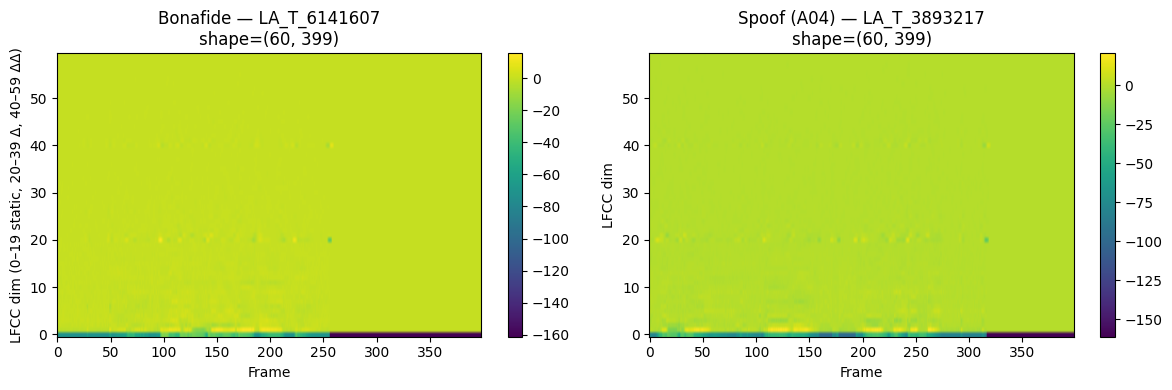

In [9]:
# Visualize one bonafide and one spoof sample
feat_dir = os.path.join(CONFIG["data_dir"], "train", "features")
with open(os.path.join(feat_dir, "labels.json")) as f:
    sample_labels = json.load(f)

bonafide_sample = next(s for s in sample_labels if s["label"] == 1)
spoof_sample = next(s for s in sample_labels if s["label"] == 0)

bonafide_lfcc = np.load(os.path.join(feat_dir, f"{bonafide_sample['audio_id']}.npy"))
spoof_lfcc = np.load(os.path.join(feat_dir, f"{spoof_sample['audio_id']}.npy"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(bonafide_lfcc, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title(f"Bonafide — {bonafide_sample['audio_id']}\nshape={bonafide_lfcc.shape}")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("LFCC dim (0–19 static, 20–39 Δ, 40–59 ΔΔ)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(spoof_lfcc, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title(f"Spoof ({spoof_sample['system_id']}) — {spoof_sample['audio_id']}\nshape={spoof_lfcc.shape}")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("LFCC dim")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

## Step 3 — PyTorch `Dataset`

Loads cached `.npy` features and pads/truncates each one to a fixed `max_frames` width
so they can be batched together. Returns `(tensor, label, system_id)` tuples — `system_id`
is carried through so we can do per-attack analysis later.

In [10]:
class LFCCDataset(Dataset):
    def __init__(self, feat_dir, max_frames=400):
        with open(os.path.join(feat_dir, "labels.json")) as f:
            self.labels = json.load(f)
        self.feat_dir = feat_dir
        self.max_frames = max_frames

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        entry = self.labels[idx]
        lfcc = np.load(os.path.join(self.feat_dir, f"{entry['audio_id']}.npy"))

        # Pad/truncate width
        _, n_frames = lfcc.shape
        if n_frames > self.max_frames:
            lfcc = lfcc[:, :self.max_frames]
        elif n_frames < self.max_frames:
            lfcc = np.pad(lfcc, ((0, 0), (0, self.max_frames - n_frames)))

        tensor = torch.FloatTensor(lfcc).unsqueeze(0)  # (1, 60, max_frames)
        label = entry["label"]
        system_id = entry.get("system_id", "-")

        return tensor, label, system_id

## Step 4 — Lightweight CNN (LCNN)

A 5-block conv network with **Max Feature Map (MFM)** activation instead of ReLU.
MFM splits the channel dimension in half and takes the element-wise max of the two halves —
a competitive gating mechanism that keeps only the most discriminative features. This is
particularly useful when training data is limited.

```
Input: (batch, 1, 60, 400)
  Conv(1→32) → BN → MFM → MaxPool   →  (batch, 16, 30, 200)
  Conv(16→32) → BN → MFM → MaxPool  →  (batch, 16, 15, 100)
  Conv(16→64) → BN → MFM → MaxPool  →  (batch, 32, 7, 50)
  Conv(32→64) → BN → MFM            →  (batch, 32, 7, 50)
  Conv(32→64) → BN → MFM            →  (batch, 32, 7, 50)
GlobalAvgPool → FC(32→64) → ReLU → Dropout(0.3) → FC(64→2)
Output: 2 class logits
```

~200K parameters total.

In [11]:
class MaxFeatureMap(nn.Module):
    """Max Feature Map activation — splits channels in half, takes element-wise max."""
    def forward(self, x):
        a, b = x.chunk(2, dim=1)
        return torch.max(a, b)


class LightCNN(nn.Module):
    """
    Lightweight CNN for anti-spoofing.
    5 conv blocks with MFM activation -> global avg pool -> FC classifier.
    ~200K parameters - trains fast even on CPU.
    """
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            MaxFeatureMap(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            MaxFeatureMap(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(16, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            MaxFeatureMap(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            MaxFeatureMap(),

            # Block 5
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            MaxFeatureMap(),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


# Quick parameter count
_m = LightCNN()
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"LightCNN parameters: {n_params:,}")
del _m

LightCNN parameters: 53,986


## Step 5 — Evaluation metrics

### Equal Error Rate (EER)

The standard ASVspoof metric. EER is the point on the ROC curve where the **False Acceptance Rate**
(spoof samples wrongly accepted as bonafide) equals the **False Rejection Rate**
(bonafide samples wrongly rejected as spoof).

Lower is better. An EER of 0% means perfect separation; 50% means random guessing.

### Per-attack EER

We also break EER down by attack type (A01–A06) — this shows which spoofing methods
the model finds easy vs. hard.

In [12]:
def compute_eer(labels, scores):
    """
    Compute Equal Error Rate (EER).
    EER is the point where FAR = FRR. Standard ASVspoof metric.
    """
    from sklearn.metrics import roc_curve

    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2 * 100  # percentage

    return eer


def per_attack_analysis(scores, labels, systems):
    """Break down performance by attack type."""
    results = {}

    bonafide_scores = [s for s, l in zip(scores, labels) if l == 1]

    attack_scores = defaultdict(list)
    for s, l, sys_id in zip(scores, labels, systems):
        if l == 0:
            attack_scores[sys_id].append(s)

    for attack_id in sorted(attack_scores.keys()):
        attack_s = attack_scores[attack_id]
        combined_labels = [1] * len(bonafide_scores) + [0] * len(attack_s)
        combined_scores = bonafide_scores + attack_s

        if len(set(combined_labels)) < 2:
            results[attack_id] = {"eer": float("nan"), "n_samples": len(attack_s)}
            continue

        eer = compute_eer(np.array(combined_labels), np.array(combined_scores))
        results[attack_id] = {
            "eer": eer,
            "n_samples": len(attack_s),
            "mean_score": np.mean(attack_s),
        }

    return results

## Step 6 — Train the LCNN

Trains for `CONFIG["epochs"]` epochs with:
- **Adam optimizer** (`lr=1e-4`, `weight_decay=1e-4`)
- **Weighted cross-entropy** to handle the slight bonafide/spoof imbalance
- **Per-epoch dev evaluation** with EER, accuracy, and loss

You should see train loss decrease steadily and dev EER come down. With only ~100 training
samples expect dev EER around **15–35%**.

In [13]:
def train_model(config):
    """Train the LCNN and return training history."""
    device = config["device"]
    print(f"  Device: {device}")

    train_ds = LFCCDataset(
        os.path.join(config["data_dir"], "train", "features"),
        max_frames=config["max_frames"],
    )
    dev_ds = LFCCDataset(
        os.path.join(config["data_dir"], "dev", "features"),
        max_frames=config["max_frames"],
    )

    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    dev_loader = DataLoader(dev_ds, batch_size=config["batch_size"], shuffle=False)

    print(f"  Train: {len(train_ds)} samples ({sum(1 for l in train_ds.labels if l['label']==1)} bonafide, "
          f"{sum(1 for l in train_ds.labels if l['label']==0)} spoof)")
    print(f"  Dev:   {len(dev_ds)} samples ({sum(1 for l in dev_ds.labels if l['label']==1)} bonafide, "
          f"{sum(1 for l in dev_ds.labels if l['label']==0)} spoof)")

    model = LightCNN(in_channels=1, num_classes=2).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Model parameters: {n_params:,}")

    # Class weights for slight imbalance
    n_bonafide = sum(1 for l in train_ds.labels if l["label"] == 1)
    n_spoof = sum(1 for l in train_ds.labels if l["label"] == 0)
    weight = torch.FloatTensor([n_bonafide / (n_bonafide + n_spoof),
                                 n_spoof / (n_bonafide + n_spoof)]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weight)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])

    history = {"train_loss": [], "dev_loss": [], "dev_acc": [], "dev_eer": []}

    for epoch in range(config["epochs"]):
        # --- Train ---
        model.train()
        train_loss = 0
        for features, labels, _ in train_loader:
            features = features.to(device)
            labels = torch.LongTensor(labels).to(device)

            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # --- Evaluate ---
        model.eval()
        dev_loss = 0
        all_scores = []
        all_labels = []
        all_systems = []

        with torch.no_grad():
            for features, labels, systems in dev_loader:
                features = features.to(device)
                labels_tensor = torch.LongTensor(labels).to(device)

                outputs = model(features)
                loss = criterion(outputs, labels_tensor)
                dev_loss += loss.item()

                scores = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                all_scores.extend(scores)
                all_labels.extend(labels)
                all_systems.extend(systems)

        dev_loss /= len(dev_loader)

        eer = compute_eer(np.array(all_labels), np.array(all_scores))
        preds = (np.array(all_scores) > 0.5).astype(int)
        acc = (preds == np.array(all_labels)).mean() * 100

        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_loss)
        history["dev_acc"].append(acc)
        history["dev_eer"].append(eer)

        print(f"  Epoch {epoch+1:2d}/{config['epochs']} | "
              f"Train loss: {train_loss:.4f} | "
              f"Dev loss: {dev_loss:.4f} | "
              f"Dev acc: {acc:.1f}% | "
              f"Dev EER: {eer:.2f}%")

    # Save model
    model_path = os.path.join(config["output_dir"], "lcnn_poc.pth")
    torch.save(model.state_dict(), model_path)
    print(f"\n  Model saved: {model_path}")

    return model, history, all_scores, all_labels, all_systems

In [15]:
# Run training
print("=" * 60)
print("STEP 3: Training LCNN")
print("=" * 60)

t_start = time.time()
model, history, scores, labels, systems = train_model(CONFIG)
print(f"\n  Training time: {time.time() - t_start:.0f} seconds")

STEP 3: Training LCNN
  Device: cpu
  Train: 104 samples (50 bonafide, 54 spoof)
  Dev:   60 samples (30 bonafide, 30 spoof)
  Model parameters: 53,986
  Epoch  1/20 | Train loss: 0.6788 | Dev loss: 0.6954 | Dev acc: 50.0% | Dev EER: 56.67%
  Epoch  2/20 | Train loss: 0.6837 | Dev loss: 0.6958 | Dev acc: 50.0% | Dev EER: 56.67%
  Epoch  3/20 | Train loss: 0.6923 | Dev loss: 0.6954 | Dev acc: 50.0% | Dev EER: 58.33%
  Epoch  4/20 | Train loss: 0.6777 | Dev loss: 0.6951 | Dev acc: 50.0% | Dev EER: 56.67%
  Epoch  5/20 | Train loss: 0.6756 | Dev loss: 0.6936 | Dev acc: 51.7% | Dev EER: 51.67%
  Epoch  6/20 | Train loss: 0.6656 | Dev loss: 0.6910 | Dev acc: 51.7% | Dev EER: 50.00%
  Epoch  7/20 | Train loss: 0.6756 | Dev loss: 0.6863 | Dev acc: 48.3% | Dev EER: 55.00%
  Epoch  8/20 | Train loss: 0.6786 | Dev loss: 0.6840 | Dev acc: 53.3% | Dev EER: 51.67%
  Epoch  9/20 | Train loss: 0.6628 | Dev loss: 0.6766 | Dev acc: 60.0% | Dev EER: 48.33%
  Epoch 10/20 | Train loss: 0.6603 | Dev loss: 

## Step 7 — Report plots

Three figures for the mid-report:

1. **Training curves** — train/dev loss + dev EER over epochs (shows the model is learning)
2. **Score distribution** — histogram of bonafide vs spoof scores (shows class separation)
3. **Per-attack EER** — bar chart of EER per attack type (shows which attacks are harder)

All three are also saved to `poc_results/` for inclusion in the report.

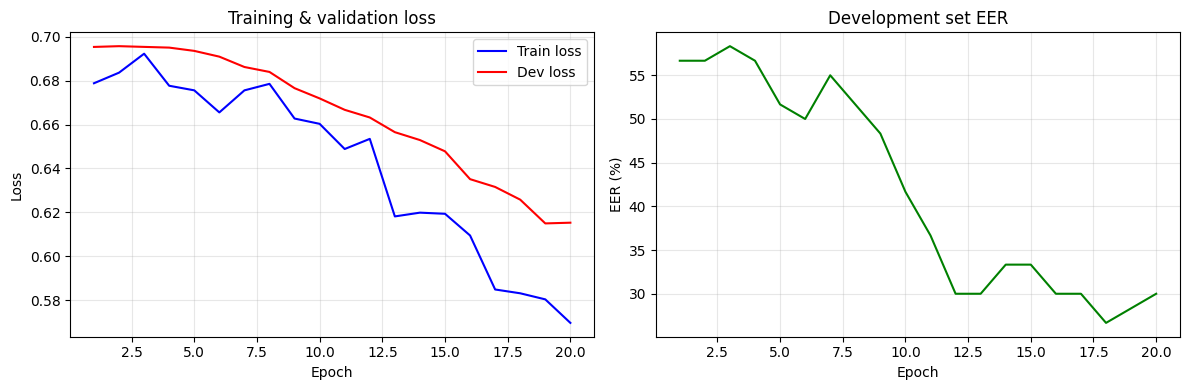

In [16]:
# --- Plot 1: Training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_x = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_x, history["train_loss"], "b-", label="Train loss", linewidth=1.5)
ax1.plot(epochs_x, history["dev_loss"], "r-", label="Dev loss", linewidth=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & validation loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_x, history["dev_eer"], "g-", linewidth=1.5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("EER (%)")
ax2.set_title("Development set EER")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

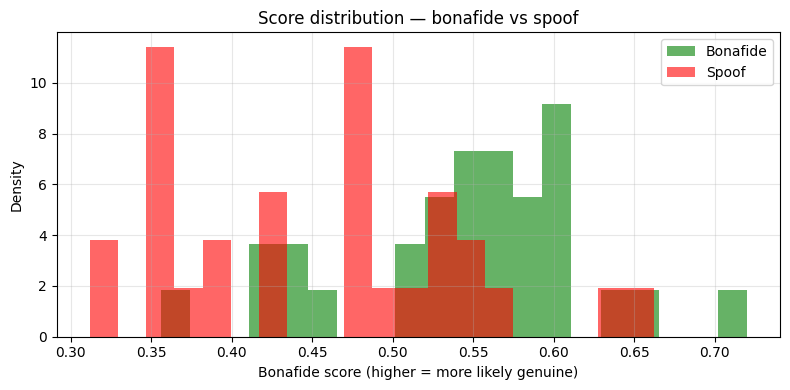

In [17]:
# --- Plot 2: Score distribution ---
fig, ax = plt.subplots(figsize=(8, 4))

bonafide_scores = [s for s, l in zip(scores, labels) if l == 1]
spoof_scores = [s for s, l in zip(scores, labels) if l == 0]

ax.hist(bonafide_scores, bins=20, alpha=0.6, label="Bonafide", color="green", density=True)
ax.hist(spoof_scores, bins=20, alpha=0.6, label="Spoof", color="red", density=True)
ax.set_xlabel("Bonafide score (higher = more likely genuine)")
ax.set_ylabel("Density")
ax.set_title("Score distribution — bonafide vs spoof")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "score_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

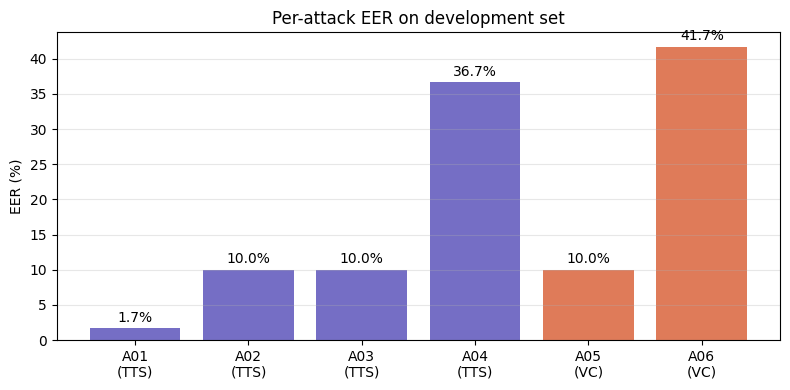

In [18]:
# --- Plot 3: Per-attack EER ---
attack_results = per_attack_analysis(scores, labels, systems)

if attack_results:
    fig, ax = plt.subplots(figsize=(8, 4))

    attacks = sorted(attack_results.keys())
    eers = [attack_results[a]["eer"] for a in attacks]
    colors = ["#1D9E75" if a.startswith("-") else
              "#534AB7" if a in ["A01", "A02", "A03", "A04"] else
              "#D85A30" for a in attacks]
    labels_text = [f"{a}\n({'TTS' if a in ['A01','A02','A03','A04'] else 'VC'})"
                   if a != "-" else "bonafide" for a in attacks]

    bars = ax.bar(labels_text, eers, color=colors, alpha=0.8)
    ax.set_ylabel("EER (%)")
    ax.set_title("Per-attack EER on development set")
    ax.grid(True, alpha=0.3, axis="y")

    for bar, eer_val in zip(bars, eers):
        if not np.isnan(eer_val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{eer_val:.1f}%", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["output_dir"], "per_attack_eer.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Not enough per-attack data for breakdown plot.")

## Step 8 — Final summary

Prints a clean summary suitable for the mid-report and saves all numbers to `results.json`.

In [19]:
def print_summary(config, history, scores, labels, systems):
    """Print a clean summary suitable for the mid-report."""
    best_epoch = int(np.argmin(history["dev_eer"]))
    best_eer = history["dev_eer"][best_epoch]
    best_acc = history["dev_acc"][best_epoch]

    attack_results = per_attack_analysis(scores, labels, systems)

    print("\n" + "=" * 60)
    print("  PRELIMINARY RESULTS SUMMARY")
    print("=" * 60)
    print(f"\n  Model:          Lightweight CNN (LCNN) with MFM activation")
    print(f"  Features:       LFCC (60-dim: 20 static + 20 delta + 20 delta-delta)")
    n_train_total = config['n_bonafide_train'] + config['n_spoof_per_attack_train']*6
    n_dev_total = config['n_bonafide_dev'] + config['n_spoof_per_attack_dev']*6
    print(f"  Training set:   {config['n_bonafide_train']} bonafide + "
          f"{config['n_spoof_per_attack_train']*6} spoof = {n_train_total} samples")
    print(f"  Dev set:        {config['n_bonafide_dev']} bonafide + "
          f"{config['n_spoof_per_attack_dev']*6} spoof = {n_dev_total} samples")
    print(f"  Epochs:         {config['epochs']}")
    print(f"  Device:         {config['device']}")
    print(f"\n  Best Dev EER:   {best_eer:.2f}% (epoch {best_epoch + 1})")
    print(f"  Best Dev Acc:   {best_acc:.1f}%")

    if attack_results:
        print(f"\n  Per-attack EER:")
        for attack_id in sorted(attack_results.keys()):
            r = attack_results[attack_id]
            attack_type = "TTS" if attack_id in ["A01", "A02", "A03", "A04"] else "VC"
            print(f"    {attack_id} ({attack_type}): EER = {r['eer']:.2f}%  (n={r['n_samples']})")

    print(f"\n  Output files:")
    print(f"    {config['output_dir']}/lcnn_poc.pth           - trained model")
    print(f"    {config['output_dir']}/training_curves.png    - loss & EER plots")
    print(f"    {config['output_dir']}/score_distribution.png - bonafide vs spoof scores")
    print(f"    {config['output_dir']}/per_attack_eer.png     - per-attack breakdown")
    print(f"    {config['output_dir']}/results.json           - all results as JSON")

    # Save JSON
    results = {
        "config": {k: str(v) for k, v in config.items()},
        "best_eer": float(best_eer),
        "best_acc": float(best_acc),
        "best_epoch": int(best_epoch + 1),
        "history": {k: [float(v) for v in vals] for k, vals in history.items()},
        "per_attack": {k: {kk: float(vv) if not isinstance(vv, int) else vv
                           for kk, vv in v.items()}
                       for k, v in attack_results.items()},
    }
    with open(os.path.join(config["output_dir"], "results.json"), "w") as f:
        json.dump(results, f, indent=2)

    print("\n" + "=" * 60)
    print("  NOTE FOR MID-REPORT")
    print("=" * 60)
    print(f"\n  These are preliminary results on a very small subset")
    print(f"  ({n_train_total} training samples). In your report, mention:\n")
    print(f"  1. This is a proof-of-concept to validate the pipeline")
    print(f"  2. The full training set has 25,380 samples (vs {n_train_total} used here)")
    print(f"  3. You plan to scale up with:")
    print(f"     - Full balanced dataset (~5,000 samples)")
    print(f"     - SSL-based approach (wav2vec 2.0 / WavLM)")
    print(f"     - Data augmentation")
    print(f"  4. Current EER of {best_eer:.2f}% is expected to improve")
    print(f"     significantly with more data and a stronger model\n")


print_summary(CONFIG, history, scores, labels, systems)


  PRELIMINARY RESULTS SUMMARY

  Model:          Lightweight CNN (LCNN) with MFM activation
  Features:       LFCC (60-dim: 20 static + 20 delta + 20 delta-delta)
  Training set:   50 bonafide + 54 spoof = 104 samples
  Dev set:        30 bonafide + 30 spoof = 60 samples
  Epochs:         20
  Device:         cpu

  Best Dev EER:   26.67% (epoch 18)
  Best Dev Acc:   63.3%

  Per-attack EER:
    A01 (TTS): EER = 1.67%  (n=5)
    A02 (TTS): EER = 10.00%  (n=5)
    A03 (TTS): EER = 10.00%  (n=5)
    A04 (TTS): EER = 36.67%  (n=5)
    A05 (VC): EER = 10.00%  (n=5)
    A06 (VC): EER = 41.67%  (n=5)

  Output files:
    poc_results/lcnn_poc.pth           - trained model
    poc_results/training_curves.png    - loss & EER plots
    poc_results/score_distribution.png - bonafide vs spoof scores
    poc_results/per_attack_eer.png     - per-attack breakdown
    poc_results/results.json           - all results as JSON

  NOTE FOR MID-REPORT

  These are preliminary results on a very small subset

## Next steps

1. **Scale up data:** bump `CONFIG["n_bonafide_train"]` and `CONFIG["n_spoof_per_attack_train"]`,
   set `SKIP_DOWNLOAD = False`, and re-run.
2. **Stronger backbone:** swap LFCC + LCNN for an SSL frontend
   (wav2vec 2.0 / WavLM) with a small classifier head — typically drops EER by 5–10×.
3. **Data augmentation:** RawBoost, codec simulation, MUSAN noise — important for
   generalization to unseen attacks.
4. **Longer training + LR schedule:** cosine annealing, early stopping on dev EER.